# Wine Quality Prediction Using Data Mining Techniques
### Methods • Results • Discussion • Conclusion
**Dataset:** UCI Wine Quality (Cortez et al., 2009)  
**Goal:** Predict numeric wine quality (0–10) using regression models.


In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold, GridSearchCV
from sklearn.model_selection import cross_val_score,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,label_binarize
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.svm import SVC,SVR
from sklearn.metrics import root_mean_squared_error, accuracy_score, f1_score, classification_report # Added classification_report
from sklearn.linear_model import LinearRegression, ElasticNet, LogisticRegression # Added LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from datetime import datetime
from sklearn.ensemble import GradientBoostingRegressor

#Preprocessing the data

In [ ]:
df = pd.read_csv('wine_quality.csv', sep=',')

df['wine_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)


print(df['wine_label'].value_counts())

df.columns = [re.sub(r'[^​\w]+', '_', x) for x in df.columns.str.lower()]

df=df.dropna().drop_duplicates()

print(df['wine_label'].value_counts())
df


wine_label
0    5220
1    1277
Name: count, dtype: int64
wine_label
0    4311
1    1009
Name: count, dtype: int64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,type,wine_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,White,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,White,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,White,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,White,0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5,White,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,Red,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,Red,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,Red,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,Red,1


#Split your data into X and y and drop any unimportant variables

In [ ]:
X = df.drop(['quality','density','free_sulfur_dioxide', 'wine_label'], axis=1)
y = df['wine_label']


#Create your train/test split with a test size of 20%.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

#Creating pipeline

In [ ]:
cat_attribs=['type']

num_attribs = ['fixed_acidity',	'volatile_acidity',	'citric_acid',	'residual_sugar','chlorides',
               	'total_sulfur_dioxide','ph',	'sulphates','alcohol']

preprocessing = ColumnTransformer([
    ("standardize", StandardScaler(), num_attribs),
    ("onh", OneHotEncoder(handle_unknown='ignore'), cat_attribs)
])

pipeline = Pipeline([('prep', preprocessing)])

#Correlation matrix

#Creating a new pipeline with the Support vector regressor

In [ ]:
log_reg_clf = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

pipeline = Pipeline([('prep', preprocessing), ('clf', log_reg_clf)])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['fixed_acidity',
                                                   'volatile_acidity',
                                                   'citric_acid',
                                                   'residual_sugar',
                                                   'chlorides',
                                                   'total_sulfur_dioxide', 'ph',
                                                   'sulphates', 'alcohol']),
                                                 ('onh',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

#Creating root mean squared error on training and testing set

In [ ]:
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

accuracy_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print(f'Training Accuracy: {accuracy_train:.4f}')
print(f'Training F1-score: {f1_train:.4f}')
print(f'Test Accuracy: {accuracy_test:.4f}')
print(f'Test F1-score: {f1_test:.4f}')

Training Accuracy: 0.8266
Training F1-score: 0.3777
Test Accuracy: 0.8158
Test F1-score: 0.3423


#Summary of the model

In [ ]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89       854
           1       0.58      0.24      0.34       210

    accuracy                           0.82      1064
   macro avg       0.71      0.60      0.62      1064
weighted avg       0.79      0.82      0.78      1064



In [ ]:
from io import StringIO

# Get the classification report as a string
report_str = classification_report(y_test, y_pred, output_dict=False)

# Parse the string into a DataFrame
report_data = StringIO(report_str)
df_report = pd.read_csv(report_data, sep='\s{2,}', engine='python', header=0, index_col=0)

# Remove the 'accuracy' row and 'macro avg', 'weighted avg' rows for direct class metrics
df_report = df_report.drop(index=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

def generate_latex_classification_report(df_report, caption="Classification Report", label="tab:classification_report"):
    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    latex_table += f"\\caption{{{caption}}}\n"
    latex_table += f"\\label{{{label}}}\n"
    latex_table += "\\begin{tabular}{lrrrr}\n"
    latex_table += "\\toprule\n"
    latex_table += "Class & Precision & Recall & F1-Score & Support\\\\\n"
    latex_table += "\\midrule\n"

    for index, row in df_report.iterrows():
        latex_table += f"{index} & {row['precision']:.2f} & {row['recall']:.2f} & {row['f1-score']:.2f} & {int(row['support'])}\\\\\\n"
    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\end{table}\n"
    return latex_table

latex_classification_report = generate_latex_classification_report(df_report)
print(latex_classification_report)

\begin{table}[ht]
\centering
\caption{Classification Report}
\label{tab:classification_report}
\begin{tabular}{lrrrr}
\toprule
Class & Precision & Recall & F1-Score & Support\\
\midrule
0 & 0.84 & 0.96 & 0.89 & 854\\\n1 & 0.58 & 0.24 & 0.34 & 210\\\n\bottomrule
\end{tabular}
\end{table}



<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-464166859.py:8: SyntaxWarning: invalid escape sequence '\s'
  df_report = pd.read_csv(report_data, sep='\s{2,}', engine='python', header=0, index_col=0)


##Confusion matrix

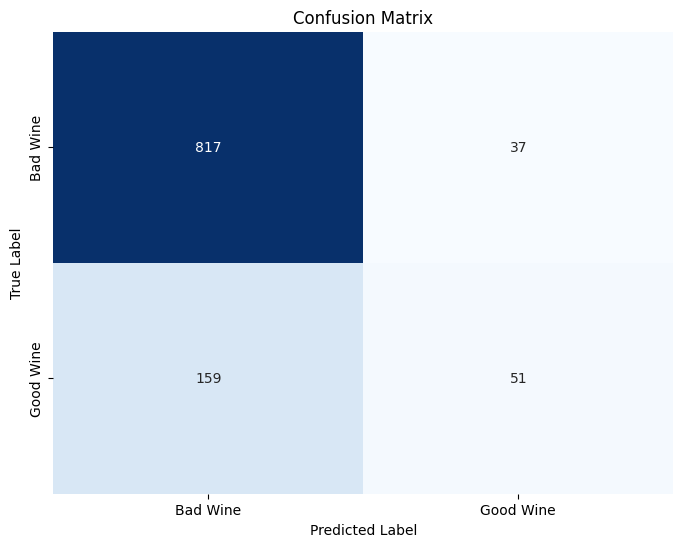


LaTeX Code for Confusion Matrix:
\begin{table}[ht]
\centering
\caption{Confusion Matrix}
\label{tab:confusion_matrix}
\begin{tabular}{|c|c|c|}
\hline
\multicolumn{3}{|c|}{Predicted}\\\n\cline{2-3}
Actual & Bad Wine & Good Wine \\
\hline
Bad Wine & 817 & 37 \\
Good Wine & 159 & 51 \\
\hline
\end{tabular}
\end{table}



array([[817,  37],
       [159,  51]])

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define custom labels for the confusion matrix
custom_labels = ['Bad Wine', 'Good Wine']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=custom_labels,
            yticklabels=custom_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate LaTeX code for the confusion matrix
def generate_latex_confusion_matrix(cm, caption="Confusion Matrix", label="tab:confusion_matrix", labels=['0', '1']):
    latex_table = "\\begin{table}[ht]\n"
    latex_table += "\\centering\n"
    latex_table += f"\\caption{{{caption}}}\n"
    latex_table += f"\\label{{{label}}}\n"
    latex_table += "\\begin{tabular}{|c|c|c|}\n"
    latex_table += "\\hline\n"
    latex_table += "\\multicolumn{3}{|c|}{Predicted}\\\\\\n"
    latex_table += "\\cline{2-3}\n"
    latex_table += f"Actual & {labels[0]} & {labels[1]} \\\\\n"
    latex_table += "\\hline\n"
    latex_table += f"{labels[0]} & {cm[0,0]} & {cm[0,1]} \\\\\n"
    latex_table += f"{labels[1]} & {cm[1,0]} & {cm[1,1]} \\\\\n"
    latex_table += "\\hline\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\end{table}\n"
    return latex_table

latex_cm = generate_latex_confusion_matrix(cm, labels=custom_labels)
print("\nLaTeX Code for Confusion Matrix:")
print(latex_cm)
cm

##Receiver Operating Characteristic Area Under the Curve(ROC AUC)

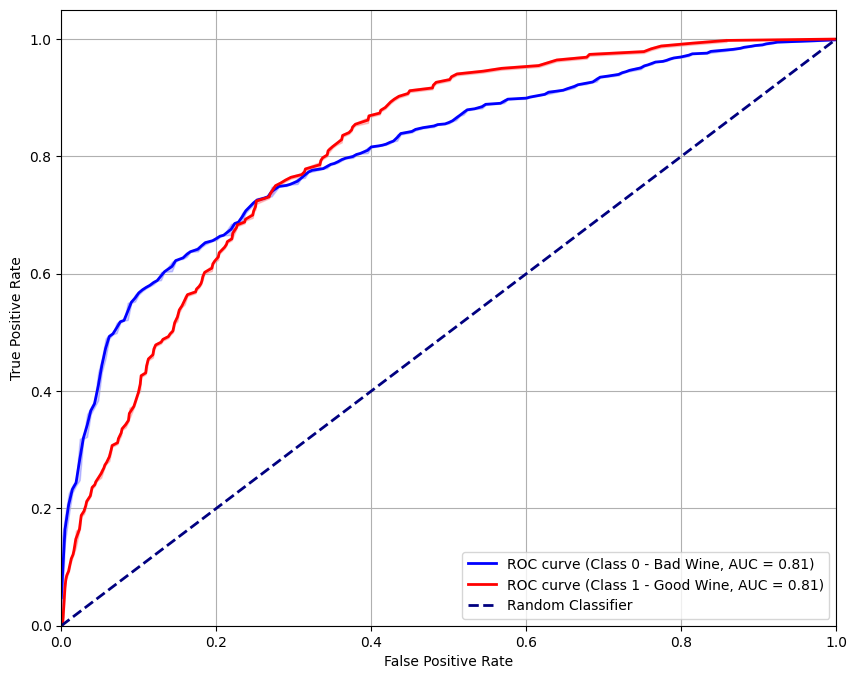

ROC curve saved as 'roc_curve_per_class_logistic.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


LaTeX Code for ROC Curve:

\begin{figure}[ht]
    \centering
    \includegraphics[width=0.8\textwidth]{roc_curve_per_class_logistic.pdf}
    \caption{Receiver Operating Characteristic (ROC) Curve for Wine Quality Prediction (Per Class)}
    \label{fig:roc_curve_per_class}
\end{figure}



In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

# Get probability predictions for both classes
y_pred_proba = pipeline.predict_proba(X_test)

# Calculate ROC curve for Class 0 (Bad Wine)
fpr_class0, tpr_class0, _ = roc_curve(y_test, y_pred_proba[:, 0], pos_label=0)
roc_auc_class0 = auc(fpr_class0, tpr_class0)

# Calculate ROC curve for Class 1 (Good Wine)
fpr_class1, tpr_class1, _ = roc_curve(y_test, y_pred_proba[:, 1], pos_label=1)
roc_auc_class1 = auc(fpr_class1, tpr_class1)

# Plot ROC curves
plt.figure(figsize=(10, 8))

sns.lineplot(x=fpr_class0, y=tpr_class0, label=f'ROC curve (Class 0 - Bad Wine, AUC = {roc_auc_class0:.2f})', color='blue', lw=2)
sns.lineplot(x=fpr_class1, y=tpr_class1, label=f'ROC curve (Class 1 - Good Wine, AUC = {roc_auc_class1:.2f})', color='red', lw=2)

# Plot the random classifier line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)

roc_curve_filename = 'roc_curve_per_class_logistic.pdf'
plt.savefig(roc_curve_filename, format='pdf', bbox_inches='tight')
plt.show()

print(f"ROC curve saved as '{roc_curve_filename}'")

files.download(roc_curve_filename)

print(latex_roc_code)


###.Binary logistic regression for balance data

In [ ]:
log_clf = LogisticRegression()

logistic_bal = Pipeline([('prep', preprocessing),('smote', SMOTE(random_state=42)),('clf1', log_clf)])



logistic_bal.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('standardize',
                                                  StandardScaler(),
                                                  ['fixed_acidity',
                                                   'volatile_acidity',
                                                   'citric_acid',
                                                   'residual_sugar',
                                                   'chlorides',
                                                   'total_sulfur_dioxide', 'ph',
                                                   'sulphates', 'alcohol']),
                                                 ('onh',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf1', LogisticRegression())])

###Classification report for balanced data

In [ ]:
y_pred1 = logistic_bal.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81       854
           1       0.40      0.73      0.52       210

    accuracy                           0.73      1064
   macro avg       0.66      0.73      0.67      1064
weighted avg       0.81      0.73      0.76      1064



###Confusion matric for balanced adta

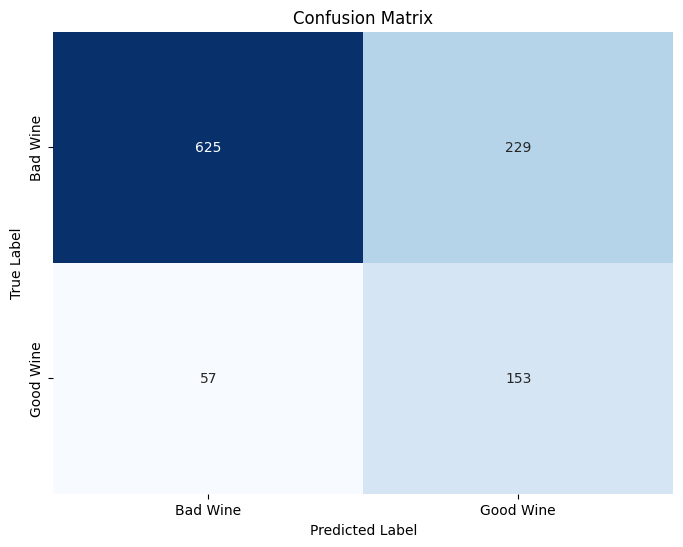

array([[625, 229],
       [ 57, 153]])

In [ ]:

cm1 = confusion_matrix(y_test, y_pred1)

# Define custom labels for the confusion matrix
custom_labels = ['Bad Wine', 'Good Wine']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=custom_labels,
            yticklabels=custom_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
cm1